# Customer Churn Analysis

## Objective

The objective of this project is to analyze customer churn behavior, identify the important factors related to churn, and generate business insights that can help reduce customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)

Dataset loaded successfully!
File name: WA_Fn-UseC_-Telco-Customer-Churn.csv


## Dataset Overview

In this section, the dataset is explored to understand its structure, number of rows and columns, data types, and basic statistical summary.

In [4]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Missing values in TotalCharges: 11


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df = df.dropna(subset=["TotalCharges"])

print("After removing missing TotalCharges rows:", df.shape)

After removing missing TotalCharges rows: (7032, 21)


In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [15]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [16]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


## Data Cleaning

In this step, the dataset was checked for missing values, duplicate rows, and incorrect data types.

The TotalCharges column was initially stored as an object data type. It was converted into numeric format using pandas. During conversion, 11 invalid or blank values were found and converted into missing values.

Since these 11 rows were very small compared to the full dataset, they were removed. After cleaning, the dataset contains 7032 rows and 21 columns with no missing values.

## Churn Distribution

The churn distribution shows how many customers stayed with the company and how many customers left.

Out of 7032 customers, 5163 customers did not churn and 1869 customers churned. The churn rate is around 26.57%, which means almost one out of four customers left the company. This is an important business concern.

In [17]:
df["Churn_Num"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["Churn", "Churn_Num"]].head()

,Churn,Churn_Num
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


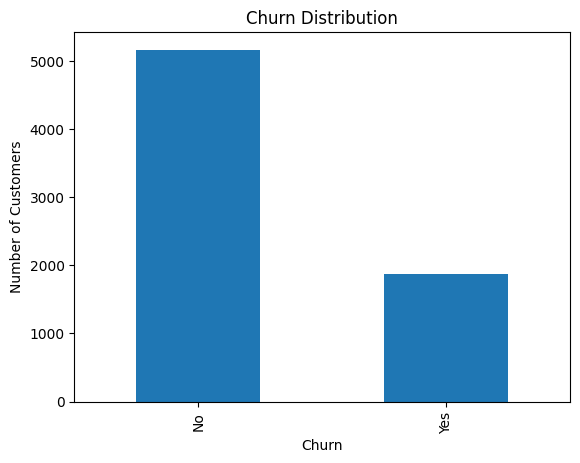

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Insight

The chart shows that most customers did not churn. However, 1869 customers churned, which is around 26.57% of the dataset. This indicates that customer churn is a significant issue for the company.

## Analyzing Customer Behavior

In this section, customer behavior is analyzed using contract type, internet service, payment method, tenure, and monthly charges. These features are selected because they are directly related to customer service usage, billing behavior, customer loyalty, and spending pattern.

In [19]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [20]:
df["Contract"].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.105233
Two year,23.961889
One year,20.932878


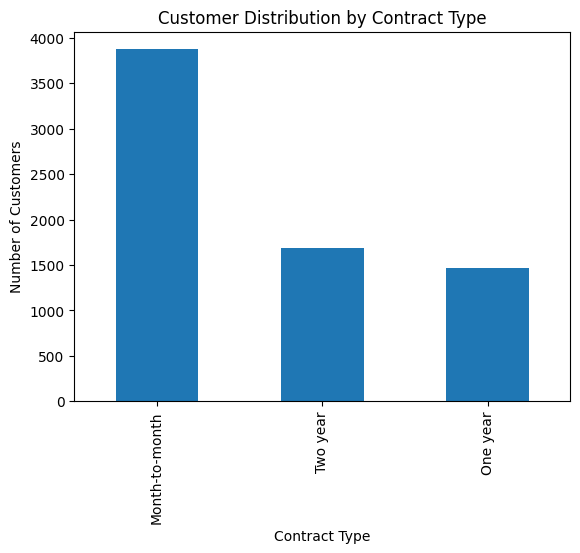

In [21]:
df["Contract"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

### Insight

This chart shows the distribution of customers based on contract type. Contract type is important because customers with different contract durations may show different loyalty behavior.

In [22]:
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


In [23]:
df["InternetService"].value_counts(normalize=True) * 100

,proportion
InternetService,
Fiber optic,44.027304
DSL,34.357224
No,21.615472


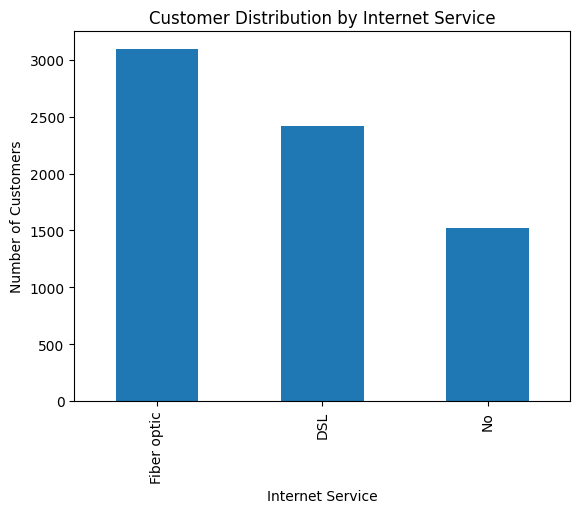

In [24]:
df["InternetService"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

### Insight

This chart shows which internet service types are used by customers. Internet service type may affect customer satisfaction, pricing expectations, and churn behavior.

In [25]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


In [26]:
df["PaymentMethod"].value_counts(normalize=True) * 100

,proportion
PaymentMethod,
Electronic check,33.631968
Mailed check,22.810011
Bank transfer (automatic),21.928328
Credit card (automatic),21.629693


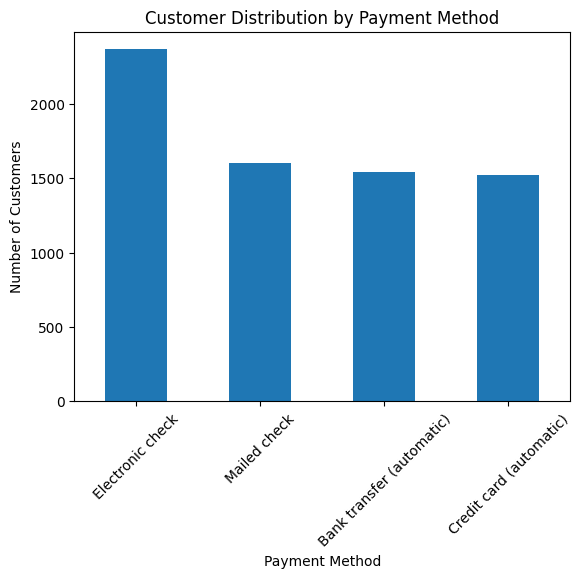

In [27]:
df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Insight

This chart shows how customers pay for the service. Payment method is important because billing convenience and payment experience may influence customer retention.

In [28]:
df["tenure"].describe()

,tenure
count,7032.000000
mean,32.421786
std,24.545260
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


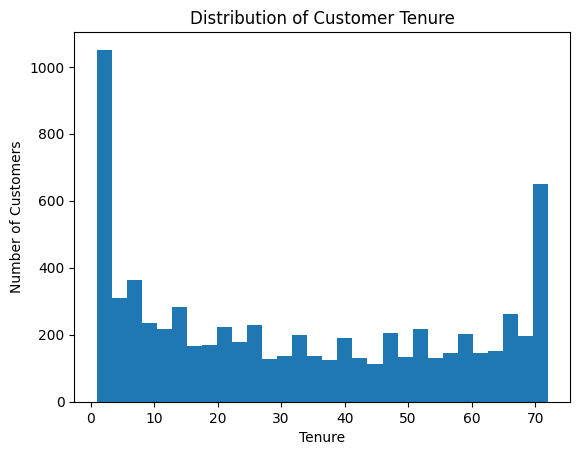

In [29]:
df["tenure"].plot(kind="hist", bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

### Insight

The tenure distribution shows how long customers have stayed with the company. This helps to understand whether the company has more new customers or long-term customers.

In [30]:
df["MonthlyCharges"].describe()

,MonthlyCharges
count,7032.000000
mean,64.798208
std,30.085974
min,18.250000
25%,35.587500
50%,70.350000
75%,89.862500
max,118.750000


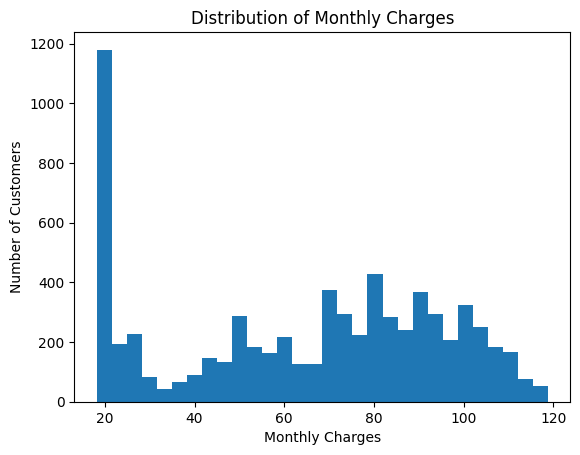

In [31]:
df["MonthlyCharges"].plot(kind="hist", bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

### Insight

The monthly charges distribution shows customer spending behavior. This helps to understand how much customers usually pay per month.

## Important Factor Analysis

In this section, important factors related to customer churn are analyzed. The analysis compares churn rate across different customer groups such as contract type, internet service, payment method, tenure, and monthly charges.

In [32]:
contract_churn = df.groupby("Contract")["Churn_Num"].mean() * 100

contract_churn.sort_values(ascending=False)

,Churn_Num
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


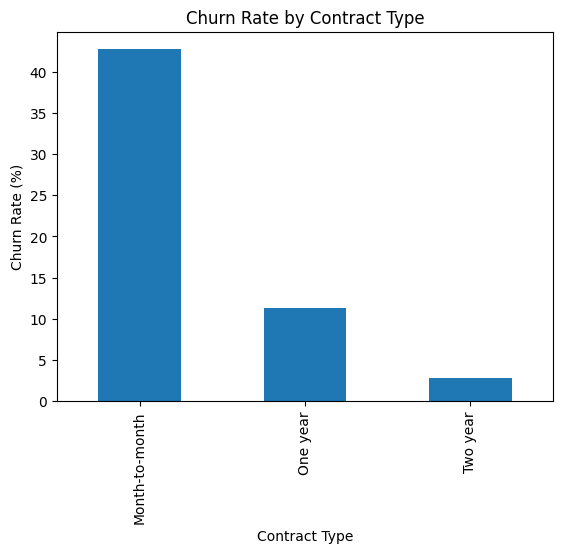

In [33]:
contract_churn.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customers with month-to-month contracts have the highest churn rate at around 42.70%. One-year contract customers have much lower churn, and two-year contract customers have the lowest churn rate.

This shows that contract type is an important factor affecting customer churn. Short-term contract customers are more likely to leave the company.

In [34]:
internet_churn = df.groupby("InternetService")["Churn_Num"].mean() * 100

internet_churn.sort_values(ascending=False)

,Churn_Num
InternetService,
Fiber optic,41.892765
DSL,18.998344
No,7.434211


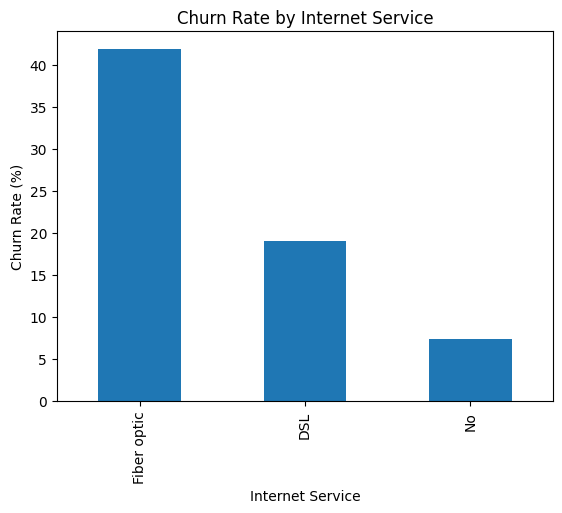

In [35]:
internet_churn.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customers using fiber optic internet service have the highest churn rate at around 41.89%. DSL customers have a lower churn rate, while customers with no internet service have the lowest churn rate.

This indicates that internet service type is an important factor related to customer churn. The high churn among fiber optic users may be connected to pricing, service quality, or customer expectations.

In [36]:
payment_churn = df.groupby("PaymentMethod")["Churn_Num"].mean() * 100

payment_churn.sort_values(ascending=False)

,Churn_Num
PaymentMethod,
Electronic check,45.285412
Mailed check,19.201995
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123


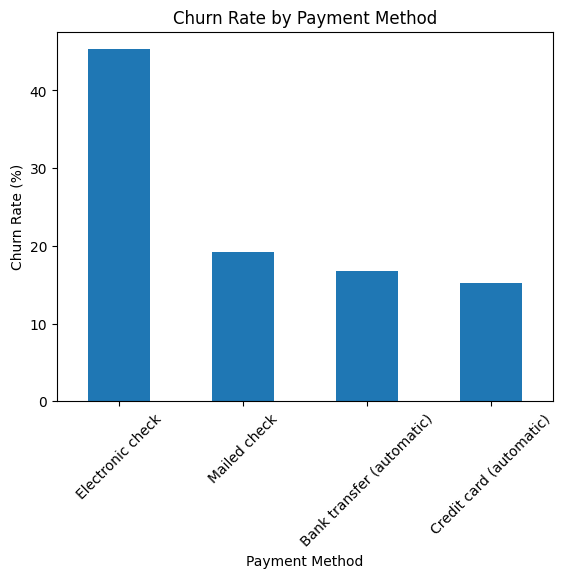

In [37]:
payment_churn.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Insight

Customers using electronic check have the highest churn rate at around 45.29%. Customers using automatic payment methods such as bank transfer and credit card have lower churn rates.

This indicates that payment method is an important factor related to customer churn. Customers using electronic check may have a weaker billing commitment or may face more payment-related inconvenience.

In [38]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


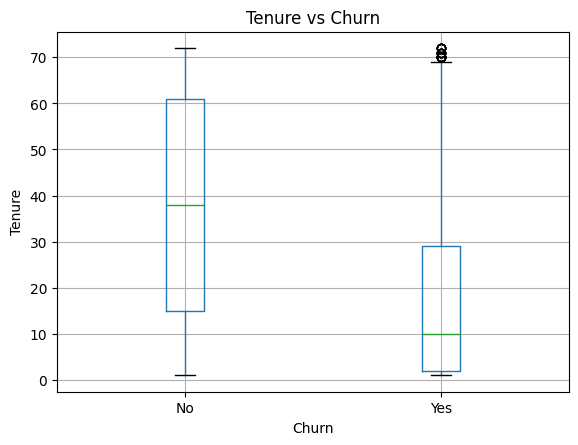

In [39]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

### Insight

Customers who churn have lower average tenure compared to customers who do not churn. The average tenure of churned customers is around 17.98 months, while non-churned customers have an average tenure of around 37.65 months.

This indicates that newer customers are more likely to leave the company. Therefore, tenure is an important factor related to customer churn.

In [40]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


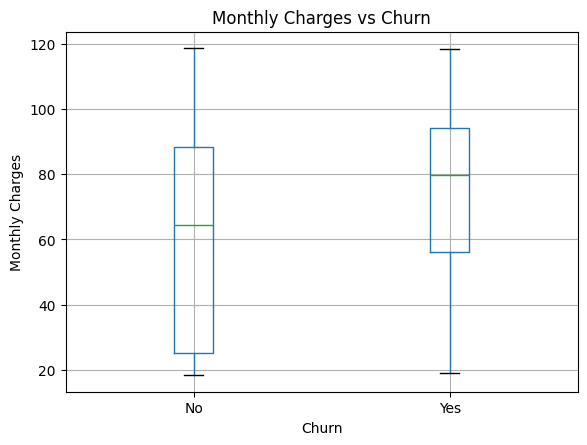

In [41]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### Insight

Customers who churn have higher average monthly charges compared to customers who do not churn. The average monthly charge for churned customers is around 74.44, while non-churned customers have an average monthly charge of around 61.31.

This indicates that monthly charges may be an important factor related to customer churn. Customers paying higher monthly charges may be more likely to leave the company.

In [42]:
security_churn = df.groupby("OnlineSecurity")["Churn_Num"].mean() * 100

security_churn.sort_values(ascending=False)

,Churn_Num
OnlineSecurity,
No,41.778667
Yes,14.640199
No internet service,7.434211


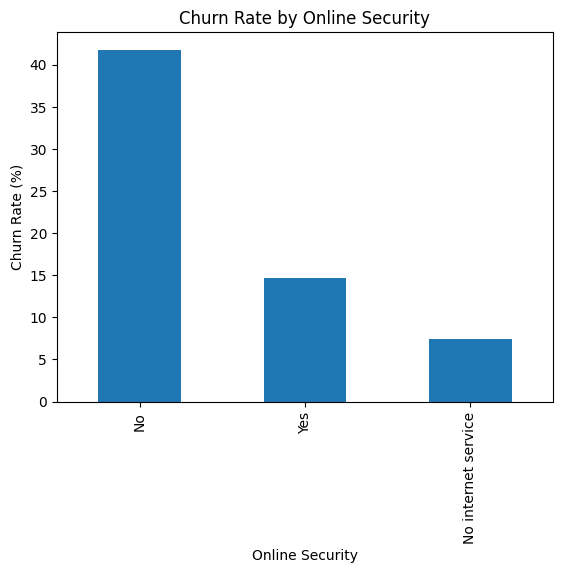

In [43]:
security_churn.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customers without online security have the highest churn rate at around 41.78%. Customers with online security have a much lower churn rate of around 14.64%.

This indicates that online security is an important factor related to customer churn. Customers who do not use online security services may be less satisfied or less engaged with the company.

In [44]:
support_churn = df.groupby("TechSupport")["Churn_Num"].mean() * 100

support_churn.sort_values(ascending=False)

,Churn_Num
TechSupport,
No,41.647465
Yes,15.196078
No internet service,7.434211


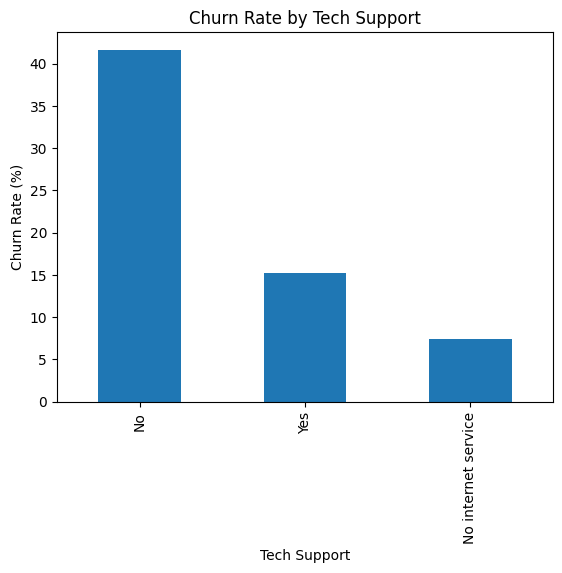

In [45]:
support_churn.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customers without tech support have the highest churn rate at around 41.65%. Customers with tech support have a much lower churn rate of around 15.20%.

This indicates that tech support is an important factor related to customer churn. Customers who do not receive technical support may be more likely to leave the company.

## Important Factors Summary

The analysis shows that several customer-related factors are strongly associated with churn. The most important factors include contract type, internet service, payment method, tenure, monthly charges, online security, and tech support.

In [46]:
important_factors_summary = pd.DataFrame({
    "Factor": [
        "Contract",
        "Internet Service",
        "Payment Method",
        "Tenure",
        "Monthly Charges",
        "Online Security",
        "Tech Support"
    ],
    "Key Finding": [
        "Month-to-month customers have the highest churn rate at around 42.70%",
        "Fiber optic customers have the highest churn rate at around 41.89%",
        "Electronic check users have the highest churn rate at around 45.29%",
        "Churned customers have lower average tenure around 17.98 months",
        "Churned customers have higher average monthly charges around 74.44",
        "Customers without online security have higher churn rate around 41.78%",
        "Customers without tech support have higher churn rate around 41.65%"
    ]
})

important_factors_summary

,Factor,Key Finding
0,Contract,Month-to-month customers have the highest chur...
1,Internet Service,Fiber optic customers have the highest churn r...
2,Payment Method,Electronic check users have the highest churn ...
3,Tenure,Churned customers have lower average tenure ar...
4,Monthly Charges,Churned customers have higher average monthly ...
5,Online Security,Customers without online security have higher ...
6,Tech Support,Customers without tech support have higher chu...


## Business Insights and Recommendations

1. Month-to-month contract customers have the highest churn rate. This shows that short-term contract customers are less loyal. The company should encourage these customers to move to one-year or two-year contracts by offering discounts, loyalty benefits, or better service packages.

2. Fiber optic internet users have a high churn rate. The company should investigate whether customers are leaving because of pricing, service quality, or support-related issues.

3. Customers using electronic check have the highest churn rate among payment methods. The company should encourage customers to use automatic payment methods such as bank transfer or credit card by offering easier billing options.

4. Customers with lower tenure are more likely to churn. The company should focus on improving onboarding, customer support, and engagement during the first few months.

5. Customers with higher monthly charges show higher churn tendency. The company can offer customized pricing plans, retention discounts, or better value packages for high-charge customers.

6. Customers without online security and tech support have higher churn rates. The company should promote these services as bundled offers to improve customer satisfaction and retention.

## Data Preprocessing Pipeline

A data preprocessing pipeline was created to prepare the cleaned dataset for future machine learning model development. The pipeline separates numerical and categorical features. Numerical features are scaled, and categorical features are converted into numerical format using OneHotEncoder.

This step does not change the original dataset. It creates a processed version of the data that can be used later for machine learning models.

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [48]:
X = df.drop(columns=["customerID", "Churn", "Churn_Num"])
y = df["Churn_Num"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [49]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [50]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [51]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

In [52]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [54]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (5625, 30)
Testing data shape after preprocessing: (1407, 30)


### Insight

The preprocessing pipeline successfully prepared the dataset for future machine learning tasks. Numerical features were scaled, and categorical features were encoded using OneHotEncoder. The original dataset was not changed; instead, a processed version of the training and testing data was created for future model development.

## Conclusion

This project analyzed customer churn behavior using the Telco Customer Churn dataset. After data cleaning and exploratory data analysis, several important factors related to churn were identified.

The analysis shows that customers with month-to-month contracts, fiber optic internet service, electronic check payment method, lower tenure, higher monthly charges, no online security, and no tech support are more likely to churn.

Based on these findings, the company should focus on customer retention strategies such as loyalty discounts, better onboarding, improved technical support, bundled security services, automatic payment options, and customized pricing plans.